 **The Capital Asset Pricing Model (CAPM):**
 
 $$
 \mathbb{E}[R_i] = r_f + \beta_i \big(\mathbb{E}[R_m] - r_f\big)
 $$
 
 - $\mathbb{E}[R_i]$ : Expected return of asset $i$
 - $r_f$ : Risk-free rate   
 - $\beta_i$ : Sensitivity (“beta”) of $i$ to market returns
 - $\mathbb{E}[R_m]$ : Expected market return
 - $\big(\mathbb{E}[R_m] - r_f\big)$ : Market risk premium
 
Reference: Sharpe, W.F. (1964). "Capital Asset Prices: A Theory of Market Equilibrium under Conditions of Risk." Journal of Finance.

 
The standard CAPM model (above) has no "alpha" term—CAPM assumes the market is efficient, so on average, all assets plot exactly on the line: 
 
$$\mathbb{E}[R_i] = r_f + \beta_i (\mathbb{E}[R_m] - r_f)$$
 
In real data, we often observe persistent deviations from this line. 
 
We capture these deviations with an **"alpha"** term by amending the regression equation:

$$
 R_i = \alpha_i + r_f + \beta_i (R_m - r_f) + \varepsilon
$$
 
Here, $\alpha_i$ (alpha) measures the excess return of asset $i$ beyond what is predicted by beta and the market, after adjusting for risk-free rate. 

If $\alpha>0$, the asset or portfolio is "beating CAPM"; if $\alpha<0$, it's underperforming.

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf
import matplotlib.ticker as mtick
import statsmodels.api as sm
from scipy import stats

### Monthly vs Daily (IMPORTANT) ###

In [30]:
monthly = False # set "monthly = false" if we're using daily returns.
# This will change the ENTIRE output of the program so use carefully.

start_date = "2023-09-01"  #Date format: yyyy-mm-dd
end_date = ""  #leave these blank ("") if no specific start / end date

ticker = "^990100-USD-STRD" #Benchmark Ticker (Yahoo Finance)

fund_data_path = "M:/_Intern Folder/Matthew/Fundsmith_Daily_Returns.xlsx"

### Data Pulling & Cleaning ###

In [31]:
# Pull historical data from yfinance starting from the year 2000
market_data = yf.download(ticker, start="2000-01-01", auto_adjust=True, multi_level_index=False) 
market_data['market_rets'] = market_data['Close'].pct_change()
market_data = market_data.dropna()
market_data

[*********************100%***********************]  1 of 1 completed


,Close,High,Low,Open,Volume,market_rets
Date,,,,,,
2000-01-04,1422.099976,1422.099976,1422.099976,1422.099976,0,0.000915
2000-01-05,1378.300049,1378.300049,1378.300049,1378.300049,0,-0.030799
2000-01-06,1359.500000,1359.500000,1359.500000,1359.500000,0,-0.013640
2000-01-07,1344.000000,1344.000000,1344.000000,1344.000000,0,-0.011401
2000-01-10,1375.800049,1375.800049,1375.800049,1375.800049,0,0.023661
...,...,...,...,...,...,...
2026-02-27,4556.799805,4574.600098,4532.500000,4566.100098,0,-0.001993
2026-03-02,4532.500000,4554.500000,4490.299805,4553.000000,0,-0.005333
2026-03-03,4456.799805,4535.600098,4396.899902,4534.500000,0,-0.016702


In [32]:
#Get returns data (depends on fund)
fund_data_path
fund_data = pd.read_excel(fund_data_path)  
fund_data = fund_data[['Date', 'Return']].dropna() # Must have only 2 columns called Date and Return (in decimals)

# Prepare fund returns
fund_data['Date'] = pd.to_datetime(fund_data['Date'])
fund_data = fund_data.set_index('Date').sort_index()
# Returns must be in decimals (no percentages)

fund_data

,Return
Date,
2013-03-15,0.008090
2013-03-18,-0.004156
2013-03-19,-0.000956
2013-03-20,0.001745
2013-03-21,0.003235
...,...
2026-02-26,0.005509
2026-02-27,0.001643
2026-03-02,-0.011529


In [33]:
# if monthly == True: 
#     ten_yr_data_path = "C:/Users/admin/Desktop/Python Projects/10_yr_treasury_monthly.csv" 
# else: 
#     ten_yr_data_path = "C:/Users/admin/Desktop/Python Projects/10_year_treasury_daily.csv"

# if monthly == True:
#     #Get 10-year treasury bill data for each month
#     rf = pd.read_csv(ten_yr_data_path) #columns are "Date" and "Yield"
#     rf['Date'] = pd.to_datetime(rf['Date'])
#     rf = rf.set_index('Date')
#     rf = rf.sort_index()

#     #De-annualize it to monthly rate, change to decimal
#     rf['Yield'] = ( (1 + rf['Yield']) ** (1/12) - 1 ) / 100
# else:
#     #Get 10-year treasury bill data for each day
#     rf = pd.read_csv(ten_yr_data_path) #columns are "Date" and "Yield"
#     rf['Date'] = pd.to_datetime(rf['Date'])
#     rf = rf.set_index('Date')
#     rf = rf.sort_index()

#     #De-annualize it to daily rate, change to decimal
#     rf['Yield'] = ( (1 + rf['Yield']) ** (1/252) - 1 ) / 100

# rf['Yield'] = rf['Yield'].ffill() #forward fill on non trading days
# rf


In [34]:
rf = yf.download("^IRX", start="2000-01-01", auto_adjust=True, multi_level_index=False)["Close"].to_frame("Yield")

rf['Yield'] = rf['Yield'].ffill() #forward fill on non trading days first

if monthly == True:
    # De-annualize it to monthly rate, change to decimal
    rf['Yield'] = ( (1 + rf['Yield'] / 100) ** (1/12) - 1 ) 
    rf = rf.resample('M').last() #resample daily rf to monthly (take last value of each month)
else: 
    # De-annualize it to daily rate, change to decimal
    rf['Yield'] = ( (1 + rf['Yield'] / 100) ** (1/252) - 1 ) 

rf.to_csv("10-yr-yield.csv")

rf

[*********************100%***********************]  1 of 1 completed


,Yield
Date,
2000-01-03,0.000204
2000-01-04,0.000204
2000-01-05,0.000204
2000-01-06,0.000203
2000-01-07,0.000202
...,...
2026-02-26,0.000140
2026-02-27,0.000140
2026-03-02,0.000140


In [35]:
#get fund returns and market returns
fund_rets = fund_data['Return']

#Change this depending on the hedge fund returns data frequency
if monthly == True: 
    market_rets = market_data['market_rets'].resample('M').apply(lambda x: (1 + x).prod() - 1) #monthly returns

    # force all dates to the calendar month end -- comment if unused
    fund_rets.index = fund_rets.index.to_period('M').to_timestamp('M')
    market_rets.index = market_rets.index.to_period('M').to_timestamp('M')
    rf.index = rf.index.to_period('M').to_timestamp('M')
else: 
    market_rets = market_data['market_rets'] #daily returns

#SANITY CHECKS
market_rets.to_csv('market_returns.csv')
rf.to_csv('risk_free_yield.csv')
fund_rets.to_csv('fund_returns.csv')

# Align series on common dates
df = pd.concat([fund_rets, market_rets, rf], axis=1, join='inner')
df.columns = ['Return', 'Market Return', 'Risk Free']

# Check if start / end date is specified
if start_date != "" and end_date != "":
    df = df.loc[start_date:end_date]
elif start_date != "" and end_date == "":
    df = df.loc[start_date:]
elif start_date == "" and end_date != "":
    df = df.loc[:end_date]

fund_data_concatenated = df.copy().drop(columns=['Market Return', 'Risk Free'])
fund_data_concatenated


,Return
Date,
2023-09-01,-0.002996
2023-09-05,-0.007090
2023-09-06,-0.005767
2023-09-07,-0.006958
2023-09-08,0.001609
...,...
2026-02-26,0.005509
2026-02-27,0.001643
2026-03-02,-0.011529


In [ ]:
removed = fund_data.reset_index().merge(fund_data_concatenated.reset_index(), how='left', indicator=True).query('_merge == "left_only"')
removed.set_index('Date')
removed

,Date,Return,_merge
0,2013-03-15,0.008090,left_only
1,2013-03-18,-0.004156,left_only
2,2013-03-19,-0.000956,left_only
3,2013-03-20,0.001745,left_only
4,2013-03-21,0.003235,left_only
...,...,...,...
3052,2025-07-04,0.000207,left_only
3092,2025-09-01,0.004369,left_only
3155,2025-11-27,-0.006137,left_only
3188,2026-01-19,-0.014587,left_only


### Finding CAPM Beta and Alpha + Testing statistical significance of Alpha ###

Alpha: 0.000044
Beta: 0.275497
R^2 = 0.070712


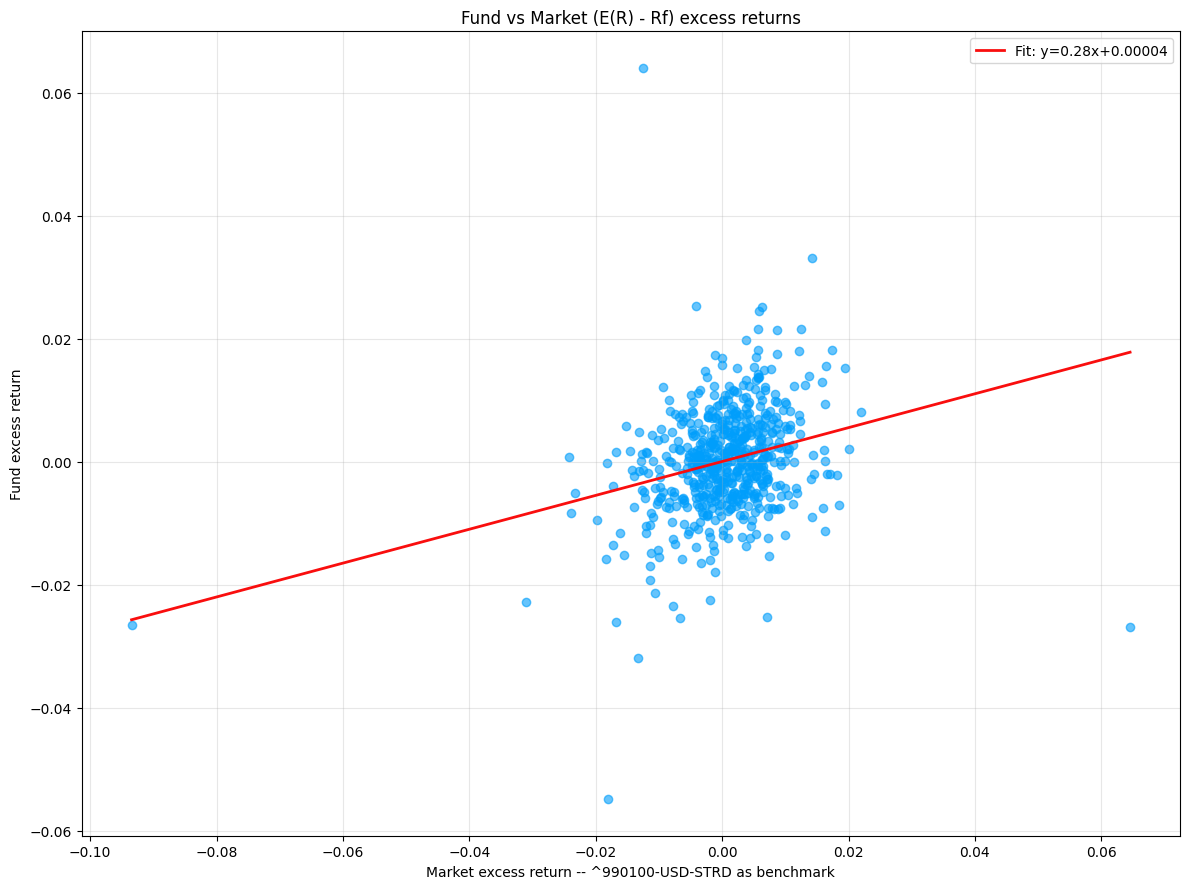

In [37]:
alpha_color = "#f90e0eff"
beta_color = '#009efb'

df['Market Excess'] = df['Market Return'] - df['Risk Free']

df['Fund Excess'] = df['Return'] - df['Risk Free']

# CAPM regression on excess returns: fund_excess = alpha + beta * market_excess
beta, alpha = np.polyfit(df['Market Excess'], df['Fund Excess'], 1)

print(f"Alpha: {alpha:.6f}")
print(f"Beta: {beta:.6f}")

# Scatter plot to display the fund's return corelation with market
x = df['Market Excess'].dropna() # x is a series
y = df['Fund Excess'].reindex(x.index).dropna()
x = x.reindex(y.index)

#find r squared for style points
y_hat = alpha + beta * x  
ss_res = ((y - y_hat) ** 2).sum()
ss_tot = ((y - y.mean()) ** 2).sum()
r2 = 1 - ss_res / ss_tot
print(f"R^2 = {r2:.6f}")

# Fitted line: y = alpha + beta * x
x_sorted = x.sort_values()
y_fit = alpha + beta * x_sorted
plt.figure(figsize=(12, 9))
plt.scatter(x, y, alpha=0.6, color=beta_color)
plt.plot(
    x_sorted,
    y_fit,
    color=alpha_color,
    linewidth=2,
    label=f"Fit: y={beta:.2f}x+{alpha:.5f}",
)
plt.xlabel(f"Market excess return -- {ticker} as benchmark")
plt.ylabel("Fund excess return")
plt.title("Fund vs Market (E(R) - Rf) excess returns")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

## Investigating Alpha Decay using Time-Series analysis ##

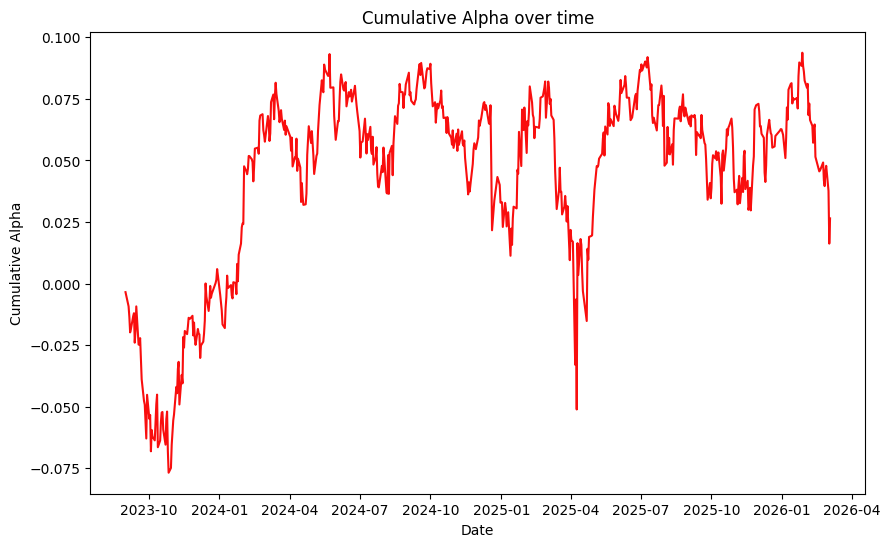

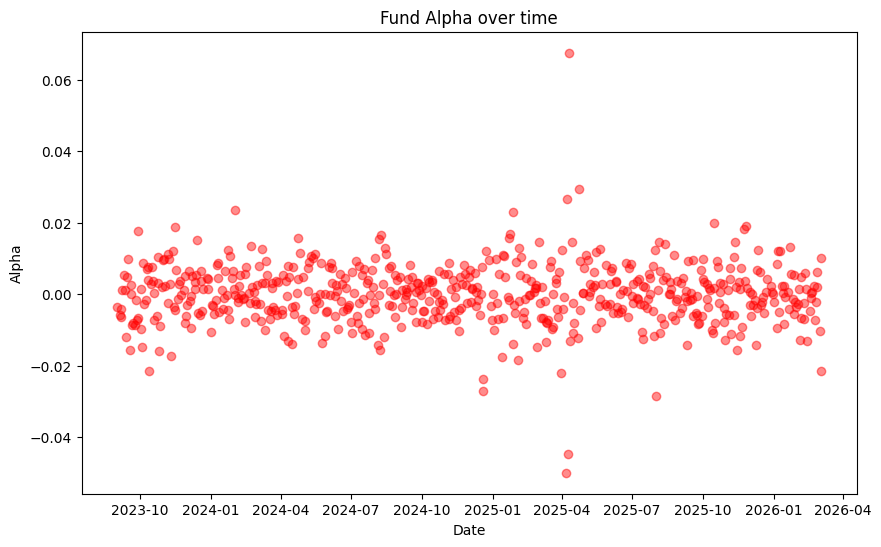

In [ ]:
df['Alpha'] = df['Fund Excess'] - (df['Market Excess'] * beta)
df['Cumulative Alpha'] = df['Alpha'].cumsum()
df

fig, ax = plt.subplots(figsize=(10,6))
plt.title("Cumulative Alpha over time")
ax.set_xlabel("Date")
ax.set_ylabel("Cumulative Alpha")
ax.plot(df.index, df['Cumulative Alpha'], color="#f90e0eff")

fig, ax = plt.subplots(figsize=(10,6))
plt.title("Fund Alpha over time")
ax.set_xlabel("Date")
ax.set_ylabel("Alpha")
plt.scatter(df.index, df['Alpha'], alpha=0.45, color="#ff0000ff")
df

df.to_csv("alpha_data_final.csv")

Paper: https://ink.library.smu.edu.sg/cgi/viewcontent.cgi?article=5734&context=lkcsb_research

"Have Capital Market Anomalies Attenuated in the Recent Era of High Liquidity and Trading Activity?" -- Section 4.3

Goal: Regress alpha data onto this curve: 

$$Y_t = a \cdot e^{bt + u_t}$$

Taking logs linearizes it: 

$$\ln(Y_t) = \ln(a) + b \cdot t + u $$

where $$Y_t = 1 + alpha_t$$

Null hypothesis: Anomalous profits (alpha) decrease exponentially over time.

Alternative hypothesis: Anomalous profits (alpha) don't decrease exponentially over time.

**Interpretation**: 

- If b < 0 and one-tailed p-value < 0.10, the strategy is experiencing statistically significant exponential decay in alpha.

- If b > 0 and one-tailed p-value < 0.10, the strategy is experiencing statistically significant exponential growth in alpha.

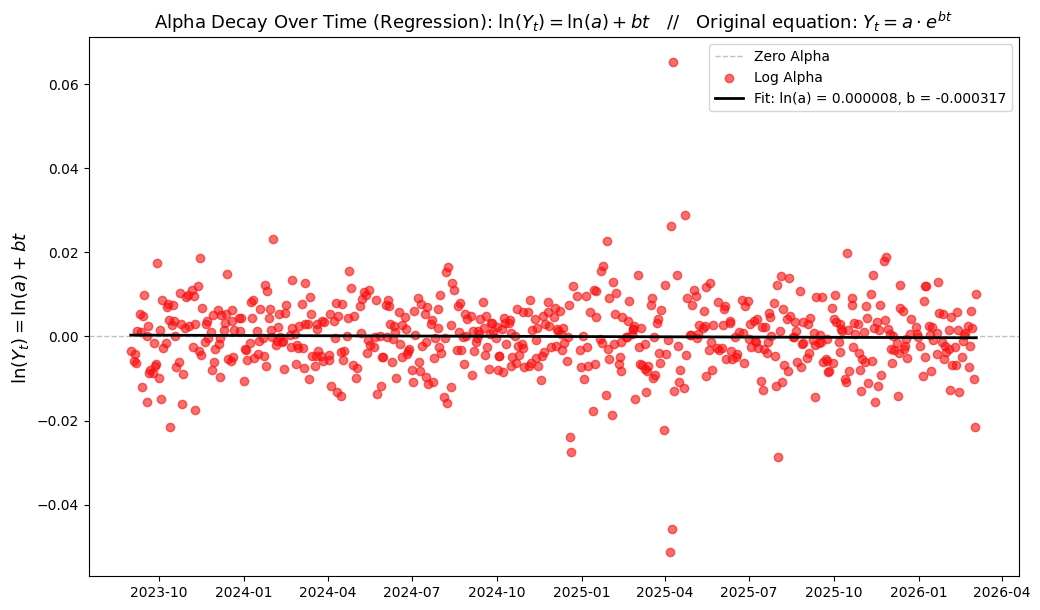

Note: This assumes that there exists a statistically significant alpha. If there is none, this decay result is pointless.
Condition: If p-value (one-tailed) < 0.1 and b < 0 (is negative), alpha decay is present at the 10% SL.
--------------------------------------------------
The p-value of the regression coefficient b (0.29742) is statistically insignificant.
There is insufficient evidence to suggest alpha decay.


In [39]:
df_alpha = df[['Alpha', 'Cumulative Alpha']].copy()
df_alpha['Log Alpha'] = np.log(1 + df_alpha['Alpha'])
df_alpha

array = np.linspace(-1, 1, len(df_alpha))
array = sm.add_constant(array)
model = sm.OLS(df_alpha['Log Alpha'], array)
results = model.fit()
# print(results.summary())

# ln_Yt = results.params['const'] + np.linspace(-1, 1, len(df_alpha)) * results.params['x1']
ln_Yt = results.fittedvalues
Y_t = np.exp(ln_Yt)

ln_a = results.params['const']
a = np.exp(ln_a)
b = results.params['x1']
p_decay_onetailed = results.pvalues['x1'] / 2
p_capm_intercept = results.pvalues['const'] / 2


fig, ax = plt.subplots(figsize=(12,7))
ax.axhline(y=0, color='gray', linestyle='--', linewidth=1, alpha=0.5, label="Zero Alpha")
plt.scatter(df_alpha.index, df_alpha['Log Alpha'], alpha=0.6, color="#f90e0eff", label="Log Alpha")
plt.title("Alpha Decay Over Time (Regression): $\ln(Y_t) = \ln(a) + bt$   //   Original equation: $Y_t = a \cdot e^{bt}$", fontsize=13)
plt.plot(
    df_alpha.index, 
    ln_Yt,
    color="#000000",
    linewidth=2,
    # label=f"Fit: ln(y_t)=ln({results.params['const']:.2f}a)+{results.params['x1']:.5f}"
    label=f"Fit: ln(a) = {ln_a:.6f}, b = {b:.6f}"
)
ax.set_ylabel("$\ln(Y_t) = \ln(a) + bt$", fontsize=13)
plt.legend()
plt.show()

print("Note: This assumes that there exists a statistically significant alpha. If there is none, this decay result is pointless.")
print("Condition: If p-value (one-tailed) < 0.1 and b < 0 (is negative), alpha decay is present at the 10% SL.")
print("-" * 50)

if p_decay_onetailed < 0.1 and b < 0: 
    print(f"The p-value of the regression coefficient b ({p_decay_onetailed:.5f}) is statistically significant.")
    print("There is sufficient evidence to suggest alpha decay.")
elif p_decay_onetailed > 0.1 and b < 0: 
    print(f"The p-value of the regression coefficient b ({p_decay_onetailed:.5f}) is statistically insignificant.")
    print("There is insufficient evidence to suggest alpha decay.")
elif b > 0 and p_decay_onetailed < 0.1: 
    print(f"The p-value of the regression coefficient coefficient b ({p_decay_onetailed:.5f}) is statistically significant.")
    print(f"Rare case: The fund's alpha actually increases over time and is significant enough.")
elif b > 0 and p_decay_onetailed > 0.1:
    print(f"b is positive but insignificant (p = {p_decay_onetailed:.5f}).")
    print("There is insufficient evidence of either decay or growth in alpha.")

### Plotting cumulative returns, Sharpe, and rolling market volatility ###

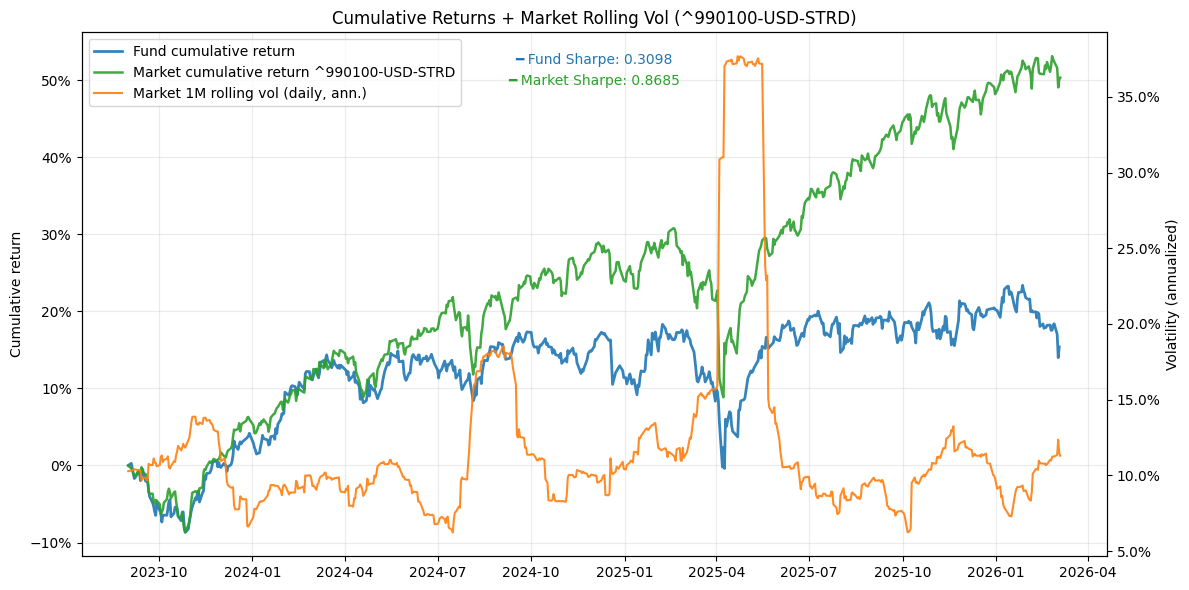

In [40]:
if monthly == True:
    #Sharpe and volatility -- monthly
    fund_excess_vol = df['Fund Excess'].std()
    fund_excess_vol_annualized = fund_excess_vol * np.sqrt(12)
    fund_sharpe_annualized = (df['Fund Excess'].mean() / fund_excess_vol) * np.sqrt(12)

    mkt_excess_vol = df['Market Excess'].std()
    mkt_excess_vol_annualized = mkt_excess_vol * np.sqrt(12)
    mkt_sharpe_annualized = (df['Market Excess'].mean() / mkt_excess_vol) * np.sqrt(12)

else:
    # Sharpe and volatility -- daily
    fund_excess_vol = df['Fund Excess'].std()
    fund_excess_vol_annualized = fund_excess_vol * np.sqrt(252)
    fund_sharpe_annualized = (df['Fund Excess'].mean() / fund_excess_vol) * np.sqrt(252)

    mkt_excess_vol = df['Market Excess'].std()
    mkt_excess_vol_annualized = mkt_excess_vol * np.sqrt(252)
    mkt_sharpe_annualized = (df['Market Excess'].mean() / mkt_excess_vol) * np.sqrt(252)

# --- Fund ---
fund_gross = (1 + fund_data["Return"].astype(float)).cumprod() #gross cumulative

if monthly == True:
    mkt_d = market_data["market_rets"].dropna().sort_index()
    mkt_d = mkt_d.resample('M').apply(lambda x: (1 + x).prod() - 1)
    mkt_d.index = mkt_d.index.to_period('M').to_timestamp('M')
else:
    mkt_d = market_data["market_rets"].astype(float).dropna().sort_index()

# Rolling vol (annualized) -- 6M window for monthly, 30-day window for daily
if monthly == True:
    mkt_vol1m_d = mkt_d.rolling(window=6).std() * np.sqrt(12)
else:
    mkt_vol1m_d = mkt_d.rolling(window=30).std() * np.sqrt(252)

# choose plot start where vol exists and fund exists
start = max(df.index.min(), mkt_vol1m_d.dropna().index.min())

# rebased fund cumulative return (starts at 0 at `start`)
fund_plot_gross = fund_gross.loc[fund_gross.index >= start]
fund_plot_cum = fund_plot_gross / fund_plot_gross.iloc[0] - 1

# rebased market cumulative return (starts at 0 at `start`)
mkt_cum_gross = (1 + mkt_d).cumprod()
base = mkt_cum_gross.loc[:start].iloc[-1]
mkt_cum_plot = mkt_cum_gross.loc[mkt_cum_gross.index >= start] / base - 1

mkt_vol_plot = mkt_vol1m_d.loc[mkt_vol1m_d.index >= start]

#Plotting
fig, ax1 = plt.subplots(figsize=(12, 6))

l1, = ax1.plot(
    fund_plot_cum.index, fund_plot_cum,
    color="tab:blue", lw=2, alpha=0.9,
    label="Fund cumulative return"
)
l2, = ax1.plot(
    mkt_cum_plot.index, mkt_cum_plot,
    color="tab:green", lw=1.8, alpha=0.9,
    label=f"Market cumulative return {ticker}"
)

ax1.set_ylabel("Cumulative return")
ax1.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax1.grid(True, alpha=0.25)

ax2 = ax1.twinx()
vol_label = "Market 6M rolling vol (monthly, ann.)" if monthly else "Market 1M rolling vol (daily, ann.)"
l3, = ax2.plot(
    mkt_vol_plot.index, mkt_vol_plot,
    color="tab:orange", lw=1.5, alpha=0.9,
    label=vol_label
)
ax2.set_ylabel("Volatility (annualized)")
ax2.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))

ax1.set_title(f"Cumulative Returns + Market Rolling Vol ({ticker})")
ax1.legend(handles=[l1, l2, l3], loc="upper left")

ax1.text(
    0.5, 0.96,
    f"━ Fund Sharpe: {fund_sharpe_annualized:.4f}",
    transform=ax1.transAxes, ha="center", va="top", color=l1.get_color()
)
ax1.text(
    0.5, 0.92,
    f"━ Market Sharpe: {mkt_sharpe_annualized:.4f}",
    transform=ax1.transAxes, ha="center", va="top", color=l2.get_color()
)

plt.tight_layout()
plt.show()

### Analysing Kurtosis & Skewness ###

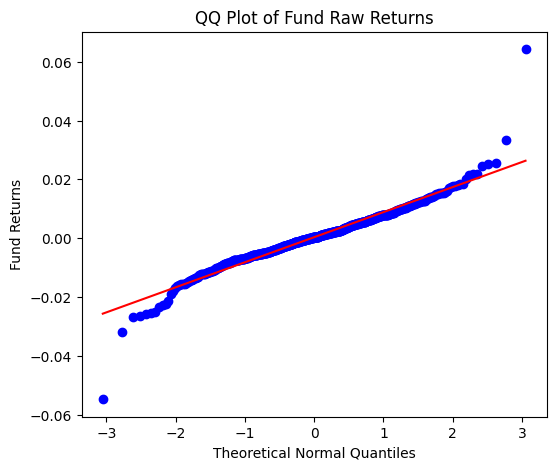

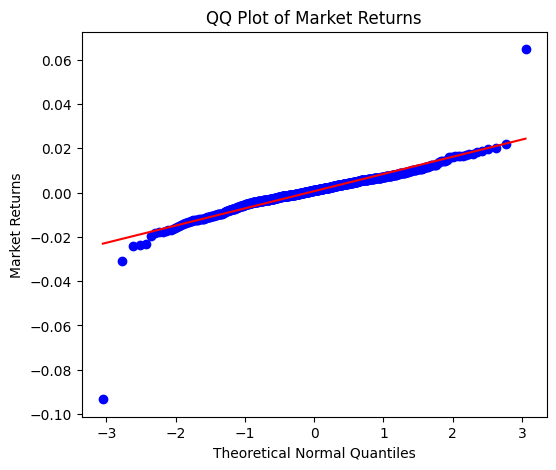

Kurtosis (Fund): 7.4263
Skewness (Fund):  0.1454

Kurtosis (Market): 29.4701
Skewness (Market):  -1.7469


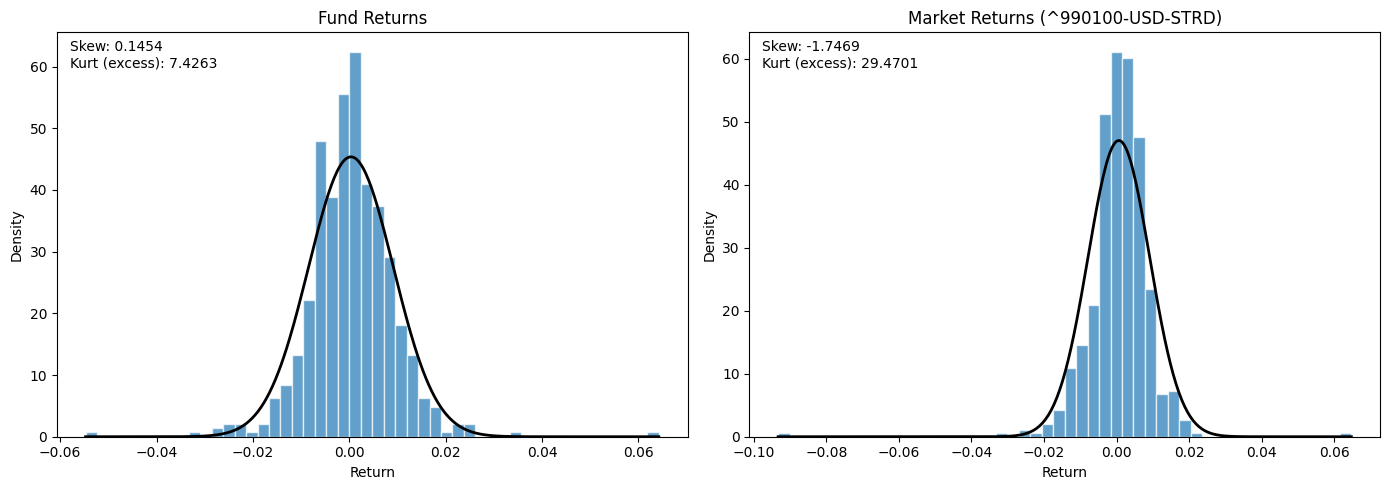

In [41]:
plt.figure(figsize=(6, 5))
stats.probplot(df['Return'], dist="norm", plot=plt)
plt.title("QQ Plot of Fund Raw Returns")
plt.ylabel("Fund Returns")
plt.xlabel("Theoretical Normal Quantiles")
plt.show()

plt.figure(figsize=(6, 5))
stats.probplot(df['Market Return'], dist="norm", plot=plt)
plt.title("QQ Plot of Market Returns")
plt.ylabel("Market Returns")
plt.xlabel("Theoretical Normal Quantiles")
plt.show()

mkt_kurtosis = df["Market Return"].kurtosis()
mkt_skew = df["Market Return"].skew()

fund_kurtosis = df['Return'].kurtosis()
fund_skew = df['Return'].skew()

print(f"Kurtosis (Fund): {fund_kurtosis:.4f}")
print(f"Skewness (Fund):  {fund_skew:.4f}")
print("")
print(f"Kurtosis (Market): {mkt_kurtosis:.4f}")
print(f"Skewness (Market):  {mkt_skew:.4f}")

def hist_with_stats(ax, s, title, xlabel):
    x = s.astype(float).replace([np.inf, -np.inf], np.nan).dropna()
    mu, sigma = x.mean(), x.std(ddof=1)

    grid = np.linspace(x.min(), x.max(), 400)
    ax.hist(x, bins=50, density=True, alpha=0.7, edgecolor="white")
    ax.plot(grid, stats.norm.pdf(grid, mu, sigma), "k", linewidth=2)

    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel("Density")
    ax.text(
        0.02, 0.98,
        f"Skew: {x.skew():.4f}\nKurt (excess): {x.kurtosis():.4f}",
        transform=ax.transAxes, va="top",
        bbox=dict(facecolor="white", alpha=0.8, edgecolor="none", boxstyle="round,pad=0.3"),
    )

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
hist_with_stats(ax1, df['Return'], "Fund Returns", "Return")
hist_with_stats(ax2, df["Market Return"], f"Market Returns ({ticker})", "Return")
plt.tight_layout()
plt.show()
